In [9]:
!pip3 install beautifulsoup4==4.12.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.9/147.9 kB 3.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.13.4
    Uninstalling beautifulsoup4-4.13.4:
      Successfully uninstalled beautifulsoup4-4.13.4


# Глубинное обучение для текстовых данных, ФКН ВШЭ
## Домашнее задание 5: Retrieval‑Augmented Generation (RAG)

## Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу — __12 баллов__.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом для пользоваться запрещается даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

__Мягкий дедлайн 04.12.25 23:59__ \
__Жесткий дедлайн 07.12.25 23:59__

### О задании

В этом домашнем задании вам предлагается реализовать ассистента для кулинарных советов с помощью RAG, который помимо всего прочего может ходить в итернет за дополнительной информацией. Всю логику системы нужно будет написать самостоятельно без специализорованных библиотек. Мы разделили ее на несколько логических компонент, каждой из которых будет отведено отдельное задание:
1. Векторная база данных с быстрым семантическим поиском
2. Разбиение текстов на куски.
3. Ранжирование документов по релевантности
4. Формирование контекста для модели и генерация ответа

### О данных

В качестве базы данных мы будем использовать пользовательские рецепты с сайта "Поваренок.Ру". Они получены с помощью веб-парсинга сайта, поэтому местами тексты недостаточно чистые. Всего в датасете содержится 84130 рецептов.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import warnings

warnings.filterwarnings('ignore')

### Загрузка датасета и модели

Таблица с рецептами хранится в файле `povarenok.csv`. Каждая запись содержит название рецепта, список ингредиентов и сам рецепт. Несмотря на то, что всего датасете хранится 84130 записей, в рамках этого задания мы будем работать с первыми 10-ю тысячами для того, чтобы все работало быстрее. При желании вы можете взять больше.

In [15]:
from datasets import load_dataset

dataset = load_dataset('csv', data_files=['povarenok.csv'], split='train')
dataset = dataset.select(range(10000))
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['name', 'ingredients', 'text'],
    num_rows: 10000
})

In [16]:
dataset[0]

{'name': 'Густой молочно-клубничный коктейль',
 'ingredients': "['Молоко', 'Клубника', 'Сахар']",
 'text': 'Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!'}

Посмотрим на распределение длин текстов. Нам важно знать с чем мы имеем дело, ведь RAG подразумевает, что мы будем подавать тексты на вход модели.

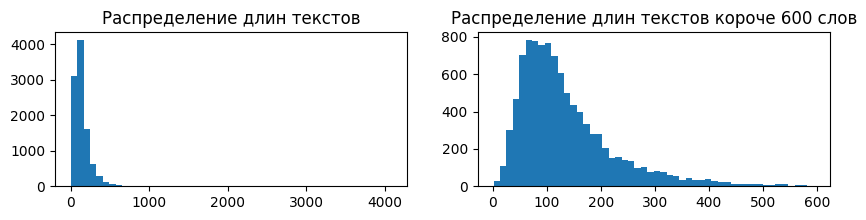

In [17]:
lens = np.array([len(dataset[i]['text'].split()) for i in range(len(dataset))])

plt.figure(figsize=(10, 2))
plt.subplot(1, 2, 1)
plt.hist(lens, bins=50)
plt.title('Распределение длин текстов')

plt.subplot(1, 2, 2)
plt.hist(lens[lens < 600], bins=50)
plt.title('Распределение длин текстов короче 600 слов')

plt.show()

Видим, что тексты часто довольно длинные. Поэтому смухлевать не получится и перед векторизацией нужно будет разбивать каждый текст на небольшие куски, чтобы не перегружать контекст модели и чтобы потерять важную информацию при векторизацци текстов на этапе складывания их в векторную базу данных.

Приступим к реализации RAG.

## Retrieval‑Augmented Generation. Подготовка

В качестве основы для ассистента возьмите модель [`Qwen/Qwen2-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2-1.5B-Instruct) из huggingface. Важно, что это `Instruct` модель, то есть она предлазначена для общения в формате диалога.

### Базовая модель

__Задание 0 (0 баллов).__ Проверьте, как модель отвечает на кулинарные вопросы без RAG. Это необходимо сделать, чтобы понять, нужен ли вообще RAG для данной задачи.

In [18]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import GenerationConfig

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

llm_model_name = "Qwen/Qwen2-1.5B-Instruct"
gen_model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    torch_dtype=torch.float16,
    device_map=device,
)
gen_tokenizer = AutoTokenizer.from_pretrained(llm_model_name)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
def generate_response(gen_model, gen_tokenizer, prompt, max_new_tokens=512):
    device = gen_model.device

    messages = [
        {"role": "system",
         "content": "You're a cooking expert and you know the recipe for any dish. "
                    "Write a list of ingredients and a step-by-step recipe for the dish. You can definitely handle it. "
                    "Write respone only in russian"},
        {"role": "user", "content": prompt}
    ]
    text = gen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = gen_tokenizer([text], return_tensors="pt").to(device)

    generated_ids = gen_model.generate(
        model_inputs.input_ids,
        max_new_tokens=max_new_tokens
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = gen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response


In [16]:
TEST_QUERIES = [
    "рецепт борща",
    "как приготовить блины",
    "овощной салат",
    "куриная грудка в духовке",
    "шоколадный торт"
]

if torch.cuda.is_available():
    for query in TEST_QUERIES:
        response = generate_response(gen_model, gen_tokenizer, query)
        print(f'Запрос:\n{query}\nОтвет:\n{response}\n\n')
        print('=' * 50)
else:
    print('NO CUDA')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Запрос:
рецепт борща
Ответ:
Борщ - это的传统ный русский суп, который готовят из мяса (обычно говядины или курицы), картофеля, пшеничной муки и различных овощей.

**Ингредиенты:**

- 2 стакана муки
- 1 стакан воды
- 300 гр мяса (например, говядина)
- 100 гр мясного бульона (или 500 мл тушёной говядины или куриной тушкой)
- 2 луковицы
- 1 зубчик чеснока
- 100 гр томатных косточек
- 100 гр помидоров
- 1/4 чайной ложки молотого черного перца
- 1/4 чайной ложки молотого белого перца
- 1 столовая ложка соли
- 1 чайная ложка сахара

**Рецепт:**

1. Нарежьте мясо на небольшие кубики.
2. В большой кастрюле разогрейте воду и добавьте немного соли.
3. Добавьте муку и начинайте медленно добавлять воду, постоянно взбивая, пока не получите однородную массу.
4. Поместите кастрюлю в духовку и выпекайте около 30 минут, периодически проверяйте состояние супа и добавляйте больше воды, если необходимо.
5. Когда суп готов, добавьте лук, чеснок, помидоры, томатные косточки, помидоры, сахар и черный перец.
6. П

> В целом похоже на рецепты, но иногда получается смешно. А еще при других запусках модель не отвечала на запрос или циклилась на списке ингредиентов.

In [20]:
del gen_model, gen_tokenizer

### Locality Sensitive Hashing (LSH)

В RAG для каждого запроса необходимо искать релевантные документы по векторной базе данных. Так как документов очень много, подсчет релевантности для каждого из них будет занимать очень много времени. Поэтому нам важно, чтобы поиск был быстрым. Для достижения этого мы даже готовы немного пожертвовать точностью.

В этой секции вам предстоит реализовать [Locality Sensitive Hashing](https://ru.wikipedia.org/wiki/Locality-sensitive_hashing).

Идея LSH довольна проста. Разделим все векторы из базы данных на группы, состоящие из похожих векторов. В начале поиска определим группу, которая соответствует вектору запроса и будем считать релевантность только для объектов из этой группы. Для разбиения на группы мы введем несколько хеш-функций. Каждая их них будет строиться по следующему алгоритму:
1. Сгенерируем $k$ случайных векторов (векторы нормали гиперплоскости)
2. Для отдельной точки (вектора) в базе данных и вектора нормали запишем 1, если точка лежит над соответствующей гиперплоскостью. В обратном случае запишем 0.
3. Повторим процедуру для всех точек и векторов нормали. Так мы для каждой точки получим список из $k$ 0 и 1, который и будет хешем.
4. Запишем в хеш-таблицу найденные точки для каждого хеша.
5. Повторим шаги 1-4 $L$ раз и получим $L$ разных хеш-таблиц.

Теперь для каждого нового вектора $q$ мы можем очень быстро найти набор векторов похожих на него. Для этого посчитаем хеши запроса в каждой хеш-таблице и возьмем все точки, у которых хеш совпал c $q$ хотя бы в одной из них. Затем переранжируем найденные точки по релевантности (расстоянию до вектора запроса) и оставим заданное число самых близких.

Сложность формирования хеш-таблиц можно оценить как $O(nLkd)$, где $n$ – число векторов в базе данных, а $d$ – размерность вектора. В то же время сложность поиска LSH – $O(Lkd + (nLp) \cdot d)$, где $p$ – вероятность того, что хеш двух случайных точек совпадет ($p$ стремится к 0). Сложность полного перебора – $O(nd)$, поэтому при поиске LSH работает быстрее почти в $\frac{n}{Lk}$ раз!

__Задание 1 (3 балла).__ Реализуйте векторную базу данных LSH поиском. База данных должна уметь добавлять новые векторы, а так же по входному вектору быстро находить ближайшие к нему. Во время создании базы данных сгенерируйте необходимое число хеш-функций. Подумайте о том, как выбрать количество хеш-таблиц и число случайных векторов, а так же о том, из какого распределения брать эти случайные векторы. При добавлении нового вектора в базу данных, считайте для него хеш и записывайте, каким группам от принадлежит.

Постарайтесь оптимизировать код и не забудьте протестировать, что ваш LSH работает так, как надо. Проще всего это сделать, построив базу данных с точками на двумерной плоскости. Также сравните скорость LSH поиска с полным перебором. Если вы все сделали правильно, то для 1000 точек вы должны получить ускорение поиска примерно в 4 раза.

> Случайные векторы будем брать из равномерного распределения на [-1, 1], чтобы вектора были распределены равномерно и не кучковались нигде, то есть чтобы хэши были более одинаково распределены. 
>
> $k$ (число случайных векторов) должно быть не очень маленьким. $p = \frac{1}{2^k}$ (вероятность того, что хэш 2 точек равен) должно быть не очень маленьким (чтобы снизить вероятность совпадения хэшей и облегчить вычисления), но и не очень большим (чтобы совпадения вообще были). Выбирать k лучше в зависимости от количества данных и желаемого ускорения.
>
> Чем больше k, тем меньше вероятность совпадения двух хэшей. Чем больше L, тем меньше вероятность совпадения хотя бы одного хэша. Чем больше L и k, тем дольше построение матриц хэшей и добавление новых векторов.
> Для примера возьму $L=10, k=8$. 

In [21]:
%load_ext autoreload
%autoreload 2

In [22]:
from vectorized_db import LSHDatabase
from testing import test_lsh_2d

lsh database created
LSH поиск: 0.000741 сек
Полный перебор: 0.003311 сек
Ускорение: 4.47x
LSH accuracy: 0.94


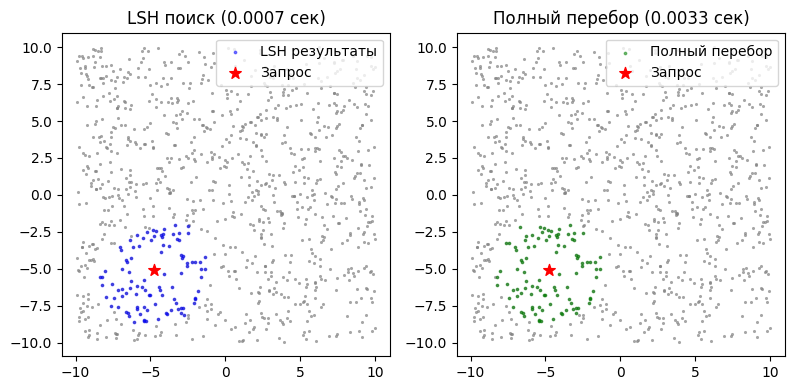

In [23]:
test_lsh_2d(num_points=1000, L=10, k=8)

lsh database created
LSH поиск: 0.005651 сек
Полный перебор: 0.033503 сек
Ускорение: 5.93x
LSH accuracy: 1.0


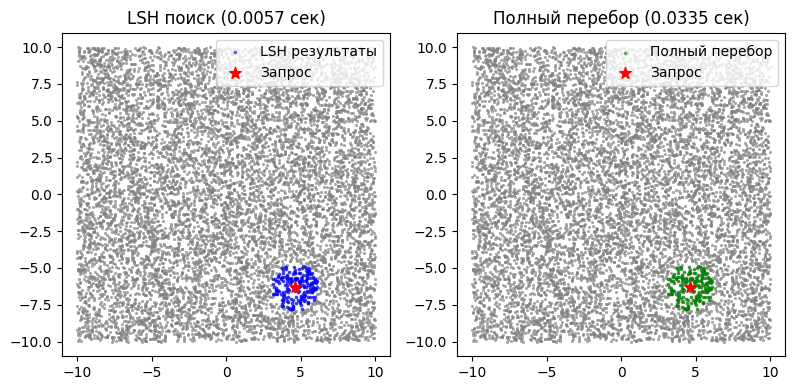

In [24]:
test_lsh_2d(num_points=10000, num_results=200, L=15, k=8)

### Разбиение текста на куски

Так как некоторые тексты довольно длинные, если мы будем кодировать их целиком одним вектором, то часть информации потеряется. Вектор все таки имеет ограниченный размер. Чтобы не терять информацию, мы поделим текст на куски и будем кодировать каждый кусок отдельно.

__Задание 2 (2 балла).__ Реализуйте [рекурсивное разбиение](https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846) текста с уровнями `["\n\n", "\n", " ", ""]`. Добавьте пересечение между кусками для уровней `[" ", ""]`. То есть если целый абзац помещается в один кусок, то пересекать его ни с чем не надо (в нем содержится законченная мысль), а если абзац не влезает и его приходится делить по словам (или символам), то нужно добавить пересечение со словами из соседних кусков того же абзаца.

Значения для максимального размера каждого куска и длины пересечения выберите самостоятельно. Надежнее всего брать размер пересечения равным половине длины куска.

In [22]:
# your code here

In [25]:
from vectorized_db import RecursiveTextSplitter

In [24]:
chunk_size = 128
splitter = RecursiveTextSplitter(
    chunk_size=chunk_size
)

sample_text = dataset[8]['text']
print(sample_text)
print('\n' + ("=" * 50) + '\n')

chunks = splitter.split_text(sample_text)

for i, chunk in enumerate(chunks):
    print(f"Чанк {i + 1} (длина: {len(chunk)}):")
    print(repr(chunk))
    print("-" * 50)

Соль по вкусу. Очищаем и нарезаем лук и морковь. Доводим лук до прозрачного состояния. Добавляем морковь и тушим 5 минут. Добавляем креветки. Тушим не боле 2 минут. Промываем рис. Равномерно выкладываем в кастрюлю или сковороду. Заливаем водой. Закрываем крышку и на среднем огне тушим 15 минут. После перемешиваем и добавляем соль и приправы. Томатная паста по вкусу. Вуаля плов готов! Хотела бы добавить, очень гармонично сочетается с пловом болгарский перец и помидор. А куркума и шафран добавил бы пряную нотку в блюдо.


Чанк 1 (длина: 121):
'Соль по вкусу. Очищаем и нарезаем лук и морковь. Доводим лук до прозрачного состояния. Добавляем морковь и тушим 5 минут.'
--------------------------------------------------
Чанк 2 (длина: 128):
'состояния. Добавляем морковь и тушим 5 минут. Добавляем креветки. Тушим не боле 2 минут. Промываем рис. Равномерно выкладываем в'
--------------------------------------------------
Чанк 3 (длина: 128):
'боле 2 минут. Промываем рис. Равномерно выкладываем в

> Для примера тут поставила 128, чтобы строчки влезли по длине на экран для удобного просмотра. Вообще для модели в будущем лучше захватить больше контекста и ставить длину чанка хотя бы $512-1024$, но слишком большую длину обрабатывать ей может быть сложно

In [26]:
splitter = RecursiveTextSplitter(
    chunk_size=300,
    chunk_overlap=50,

)
recipes_chunks = [splitter.split_text(f"Блюдо\n{item['name']}\n\nРецепт\n{item['text']}") for item in dataset]

In [25]:
del splitter, chunks

In [39]:
del recipes_chunks

## RAG

Наконец мы можем начать собирать систему RAG. Для начала соберем векторую базу данных из кусков рецептов. Для получения эмбеддингов текстов возьмите модель [`intfloat/multilingual-e5-large`](https://huggingface.co/intfloat/multilingual-e5-large), она создана специально для этой задачи и хорошо работает с русским языком.

### Векторная база данных

__Задание 3 (1 балл).__ Соберите векторую базу данных с помощью написанных вами функций. Процесс не должен занимать много времени с GPU, но мы рекомендуем сохранить результат на диск, чтобы не векторизовать весь датасет заново при перезапуске ядра. Проверьте, что по запросу возвращаются релевантные тексты.

In [27]:
# your code here

In [26]:
from vectorized_db import Embedder
from testing import test_search

In [27]:
from transformers import AutoTokenizer, AutoModel

emb_model_name = 'intfloat/multilingual-e5-large'
_ = AutoTokenizer.from_pretrained(emb_model_name, force_download=True)
_ = AutoModel.from_pretrained(emb_model_name, force_download=True)

db_file = "recipes_database.pkl"

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

In [30]:
import pickle
import os
import tqdm


def save_database(database, file_path):
    with open(file_path, 'wb') as f:
        pickle.dump(database, f)


def load_database(file_path):
    with open(file_path, 'rb') as f:
        database = pickle.load(f)
    return database


In [31]:
def create_vectorized_db(db_file, emb_model_name, recipes_chunks, test_queries=None, lsh_k=6, lsh_L=10):
    if os.path.exists(db_file):
        print(f"Найден сохраненный файл базы данных: {db_file}")
        database = load_database(db_file)
        embedder = Embedder(emb_model_name)
        if test_queries is not None:
            test_search(database, embedder, test_queries, dataset, print_recipe=False)
        return

    print("\n1. Инициализация модели для эмбеддингов")
    embedder = Embedder(emb_model_name)

    print("\n2. Создание векторной базы данных")
    database = LSHDatabase(dim=embedder.embedding_dim, k=lsh_k, L=lsh_L)
    n_recepies = len(recipes_chunks)
    pbar = tqdm.tqdm(total=n_recepies)
    for item_id, item in enumerate(recipes_chunks):
        embeddings = embedder.encode(item)
        metadata = [{'text': item_, 'id': item_id} for item_ in item]
        database.add_batch_vectors(embeddings, metadata)
        pbar.update(1)

    print("\n3. Сохранение базы данных")
    save_database(database, db_file)

    if test_queries is not None:
        print("\n4. Тестирование поиска")
        test_search(database, embedder, test_queries, dataset, print_recipe=False)


create_vectorized_db(db_file, emb_model_name, recipes_chunks, TEST_QUERIES)

Найден сохраненный файл базы данных: recipes_database.pkl
Запрос 1:
рецепт борща
1. Рецепт № 3406, название: Заготовка на борщ
2. Рецепт № 799, название: Заправка для борща
3. Рецепт № 9465, название: Борщ для правильного питания

Запрос 2:
как приготовить блины
1. Рецепт № 1904, название: Запеченные блины с клубникой
2. Рецепт № 9238, название: Блины простые, но всегда удачные
3. Рецепт № 4589, название: Блины

Запрос 3:
овощной салат
1. Рецепт № 2649, название: Салат из свежих овощей
2. Рецепт № 3355, название: Салат овощной
3. Рецепт № 4669, название: Весенний овощной салат

Запрос 4:
куриная грудка в духовке
1. Рецепт № 8547, название: Шашлычки из куриной грудки в духовке
2. Рецепт № 300, название: Куриные грудки по-праздничному
3. Рецепт № 9385, название: Куриное филе в духовке

Запрос 5:
шоколадный торт
1. Рецепт № 9992, название: Торт "Шоколадный шоколад
2. Рецепт № 6854, название: Маленький шоколадный торт
3. Рецепт № 7020, название: Кокосовый торт



### Формирование контекста для модели и генерация ответа

Из всех компонент RAG эта самая творческая. Надо придумать промпт, который будет лучше всего помогать модели генерировать ответ.

__Задание 4 (1 балл).__ Напишите функцию для генерации ответа по текстовому запросу в парадигме RAG. Найдите релевантные документы и соберите из них промпт, объяснив дополнительно модели, что от нее требуется. Количество текстов в промпте ограничивайте отбирая топ самых релевантных. Заметьте, что в нашем датасете помимо рецепта есть список ингредиентов и название блюда. Подумайте о том, как можно их использовать. Предайте промпт в модель для получения ответа. Подберите гиперпараметры генерации, чтобы контролировать разнообразие. Помните, что модель должна строго соответствовать инструкциям, не придумывать факты и не генерировать то, что от нее не требуется. Продемонстрируйте ваши результаты на 3-5 примерах.

In [28]:
from rag_system import RecipeRAGSystem
from testing import test_rag_system

In [33]:
test_rag_system(dataset, db_file, emb_model_name, llm_model_name, TEST_QUERIES, print_metainfo=True)

Инициализация RAG системы для рецептов

Пример 1/5
Запрос: рецепт борща

1. Поиск релевантных фрагментов в базе данных
   Найдено 5 релевантных фрагментов:
   1. (№3406) Оценка: 9.40 Заготовка на борщ
   2. (№799) Оценка: 9.20 Заправка для борща
   3. (№9465) Оценка: 9.19 Борщ для правильного питания
   4. (№7674) Оценка: 9.15 Мой борщ
   5. (№1853) Оценка: 9.15 Мой борщ

2. Создание промпта с фрагментами рецептов

3. Генерация ответа
С удовольствием помогу вам с рецептом борща! 

Название блюда: Борщ
Категория: суп
Ингредиенты:
1. Горсть картофеля среднего размера
2. Горсть моркови среднего размера
3. Горсть свеклы среднего размера
4. Горсть помидоров
5. Горсть баклажана
6. Горсть луковицы среднего размера
7. Горсть горчицы (по вкусу)
8. Горсть лаврового листа
9. Горсть перец чёрного
10. Горсть соли
11. Горсть сахара
12. Горсть уксуса
13. Горсть свежего укропа
14. Горсть чеснока
15. Горсть петрушки
16. Горсть листьев лаврового
17. Горсть укропа
18. Горсть свежего перец чёрного
19. Гор

> В среднем ответы получше получились, хотя не всегда консистентные и связные. Иногда циклится на списке ингредиентов. Все еще бывают смешные моменты, но уже гораздо меньше. Жаль, что последний рецепт прервался.

### Поиск в интернете

Как вы должны были заметить, языковая модель с RAG работает куда лучше, чем без него. Несмотря на это, она все равно регулярно галлюционирует. Качество RAG подхода помимо самих компонент RAG во многом зависит от датасета и модели. Например, датасет с рецептами может не содержать каких-то фактов о самих блюдах, а некоторых блюд вообще может не быть. В таком случае модель не сможет правильно ответить на вопрос. Давайте улучшим качество формирования контекста, добавив возможность сестеме искать информацию в интернете.

__Задание 5 (2 балла).__ Модифицируйте процесс извлечения релевантных текстов следующим образом. Если в топе оказались тексты с недостаточно высокой (по порогу) похожестью на запрос, то замените их текстами, найденными по запросу в интернете, у которых похожесть достаточно высокая. Таким образом, модель всегда будет получать фиксированное число максимально релевантных текстов на вход.

При поиске в интернете мы будем пользоваться тем, что все поисковики сортируют выдачу по соответствию запросу. Значит мы можем взять наш запрос, вставить его в поисковик и пройти по выданным ссылкам, анализируя текст на каждой странице до тех пор, пока не наберем достаточное число релевантных текстов. Для хождения в интернет вам потребуется библиотека [`requests`](https://requests.readthedocs.io/en/latest/), а для извлечения текста со страницы проще всего использовать [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

Получилось ли у вас улучшить качество ответов?

In [34]:
# your code here
test_rag_system(dataset, db_file, emb_model_name, llm_model_name, TEST_QUERIES,
                rel_threshold=9.2, print_metainfo=True, use_web=True)

Инициализация RAG системы для рецептов

Пример 1/5
Запрос: рецепт борща

1. Поиск релевантных фрагментов в базе данных
   Найдено 2 релевантных фрагментов:
   1. (№3406) Оценка: 9.40 Заготовка на борщ
   2. (№799) Оценка: 9.20 Заправка для борща

1.2. Поиск релевантных рецептов в интернете
   Найдено 3 рецептов:
   1. Зажарка для борща https://food.ru/recipes/recipes/30222-zazharka-dlja-borshcha
   2. Заправка для борща https://food.ru/recipes/recipes/1638-zapravka-dlja-borshcha
   3. Неклассическая вариация борща https://food.ru/recipes/recipes/159999-neklassicheskaia-variatsiia-borshcha-1676458316

2. Создание промпта с фрагментами рецептов

3. Генерация ответа
Борщ - это классическое украинское блюдо, которое часто готовят на зимний период. Вот простой рецепт:

**Для основного борща**

1. **Ингредиенты:** 
   - 500 г мяса (например, говядины)
   - 500 г картофеля
   - 500 г свеклы
   - 500 г моркови
   - 500 г луковой шалены
   - 2 зубчика чеснока
   - 1 чашка томатной пасты
   - 1/

> Уже не циклимся на списке ингредиентов, это хорошо. Лишнего тоже не пишет. Результат стал получше, уже можно утверждать, что модель пишет рецепты, а не анекдоты

__Бонус [история] (1 балл)__. Важный недостаток текущего подхода заключается в том, что ассистенту нельзя задавать уточняющие вопросы по его же ответам. Приходится переписывать весь запрос целиком, добавляя больше деталей. Это, в целом, решение, но будет лучше, если в системе будет сохраняться история общения, а затем использоваться при генерации нового ответа. В этом задании вам предлагается добавить этот функционал. 

Существует много способов встраивания истории в модель. Например, можно просто сохранить все вопросы и ответы и подавать их в контекст. Однако такой способ значительно увеличит размер промпта, из-за чего увеличатся затраты по времени и памяти на каждый ответ. Конечно, можно попробовать фильтровывать историю, оставляя только те запросы и ответы, которые касаются текущего запроса. Тем не менее, это все еще будет перегружать промпт. Поэтому есть подход куда лучше.   
Перед поиском релевантных текстов попросим модель переформулировать полученный запрос так, чтобы он стал более полным и включал в себя контекст предыдущего общения. Например, `"Какая у него каллорийность?" -> "Какая каллорийность у салата Цезарь?"`. С таким новым запросом мы сможем искать релевантные тексты с учетом истории, не увеличивая итоговый размер промпта.

Реализуйте описанную схему. Для переформулирования запроса используйте ту же модель, что и для генерации, и убедитесь, что она хорошо справляется со своей задачей. С какими сложностями вы столкнулись?

In [35]:
# your code here

__Задание 6 (1 балл).__ Продемонстрируйте работу вашего финального ассистента в различных сценариях (разные темы вопросов, разная сложность). Приведите примеры как удачных, так и неудачных ответов. Почему ваша система не всегда работает как надо? Какие у нее есть ограничения и какие преимущества? Как вы думаете, что можно сделать, чтобы ее улучшить?

> в задании 5 уже есть примеры работы кулинарного ассистента.
> 
> одной из проблем является прерывание рецепта. для этого можно просто продолжать генерить рецепт, пока не получим eos.
>
> также рецепты из интернета можно оценивать по релевантности запросу, и тоже фильтровать. но я подумала, что это лишнее, предполагая, что поиск на food.ru уже достаточно хороший и можно взять просто топ выдачи.
>
> строгий промпт, ограничивающий модель только предоставленными примерами, нужен для минимизации галлюцинаций. но противоречия между отобранными для примера рецептами может сбивать модель и мешать обобщению для ответа

> Еще пара примеров запросов ниже

In [29]:
# your code here
queries = ['как приготовить квас?', 'что нужно для фо бо', 'что приготовить из фасоли']
test_rag_system(dataset, db_file, emb_model_name, llm_model_name, queries,
                rel_threshold=9.2, print_metainfo=True, use_web=True)

Инициализация RAG системы для рецептов

Пример 1/3
Запрос: как приготовить квас?

1. Поиск релевантных фрагментов в базе данных
   Найдено 0 релевантных фрагментов:

1.2. Поиск релевантных рецептов в интернете


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


   Найдено 5 рецептов:
   1. Квас из сухой заготовки https://food.ru/recipes/recipes/184656-kvas-iz-suhoi-zagotovki
   2. Капустный квас https://food.ru/recipes/recipes/62389-kapustnyi-kvas
   3. Хлебный квас https://food.ru/recipes/recipes/252927-khlebnyi-kvas-1747987064
   4. Домашний квас https://food.ru/recipes/recipes/31887-domashnii-kvas
   5. Хлебный квас https://food.ru/recipes/recipes/152305-khlebnyi-kvas-1668592313

2. Создание промпта с фрагментами рецептов

3. Генерация ответа
Для приготовления кваса вам понадобятся следующие ингредиенты:

1. Сухой хлебный квас
2. Сахар
3. Сухие дрожжи
4. Изюм
5. Вода

Рецепт:
1. Разложите все продукты на столе, отмерив их количество заранее. Изюм не промывайте, так как на поверхности находятся дрожжи, необходимые для брожения напитка.
2. Вскипятите воду и залейте сухой квас. Дайте смеси настояться, а через 3 часа процедите. 
3. Растворите дрожжи в небольшом количестве теплой воды и влейте в квас.
4. Добавьте в квас сахар и изюм. Дайте наст

> Со всеми 3 запросами ассистент справился четко. Только с фасолью начал придумывать блюда, которые не видел в примерах, и это может быть недостатком. 

## Бонусы

__Бонус [Self-Query] (1 балл)__. Предлагаем вам почитать про метод [SelfQuery](https://medium.com/%40danushidk507/rag-x-self-query-retriever-952dd55c68ed) и реализовать его. Если описывать вкратце: мы при помощи модели проводим предобработку запроса и выделяем из него некоторые метаданные, по которым можем фильтроваться по датасету. Например, в запросе "хочу что-то сладкое клубничное, но без манго" выделим продукты "клубника" и "манго", а дальше проведём фильтр по базе данных на основе продуктов, и в полученном подмножестве найдём "что-то сладкое".

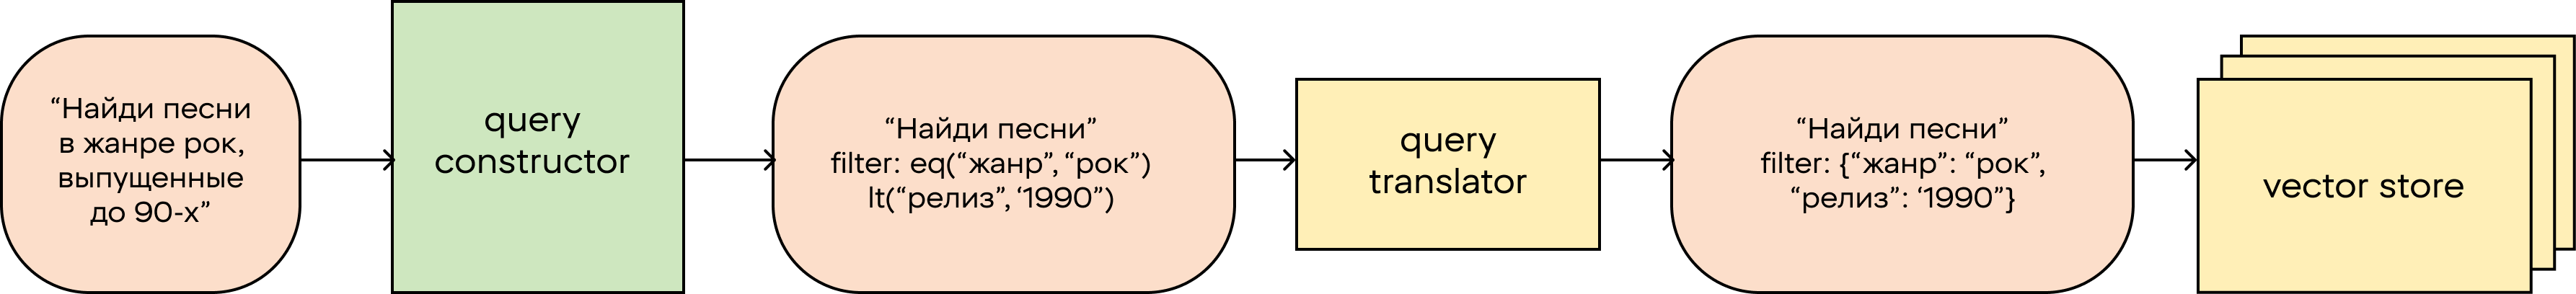

Для выделения метаданных можете воспользоваться либо генерацией json'а в определенном формате, либо SGR.

[Schema-Guided Reasoning (SGR)](https://abdullin.com/schema-guided-reasoning/) — это метод, который побуждает большие языковые модели (LLM) к созданию структурированных, понятных и предсказуемых ответов, заставляя их рассуждать по заранее определённым шагам. Создавая специальную схему (или структурированный шаблон), вы явно задаёте:

* какие этапы модель обязана пройти (не допускает пропуска или потери логики),
* в каком порядке должна происходить цепочка рассуждений (обеспечивает связность),
* на что именно следует обратить внимание (повышает глубину и точность).

Вместо свободной генерации текста — часто непоследовательной или двусмысленной — схема выступает жёстким ориентиром. Эта структура затем принудительно применяется к модели с помощью ограниченного декодирования (structured output).